In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
results = pd.read_csv("data/LightGBM_all_months_forecast_results.csv")

In [17]:
results.head()

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next
0,Akabary_Chilly,1,300.0,270.92,628.57,432.57,900.0,597.11
1,Akabary_Chilly,2,300.0,350.95,555.56,515.28,800.0,631.33
2,Akabary_Chilly,3,300.0,340.47,439.77,477.33,500.0,545.20
3,Akabary_Chilly,4,400.0,390.53,450.00,456.27,500.0,493.61
4,Amala,1,100.0,155.18,111.25,155.18,120.0,175.23


In [18]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product_Name              641 non-null    object 
 1   month_idx                 641 non-null    int64  
 2   Actual_Min_Price_next     641 non-null    float64
 3   Predicted_Min_Price_next  641 non-null    float64
 4   Actual_Avg_Price_next     641 non-null    float64
 5   Predicted_Avg_Price_next  641 non-null    float64
 6   Actual_Max_Price_next     641 non-null    float64
 7   Predicted_Max_Price_next  641 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 40.2+ KB


In [20]:
results["Min_Error"] = (
    results["Actual_Min_Price_next"] -
    results["Predicted_Min_Price_next"]
).abs()

results["Avg_Error"] = (
    results["Actual_Avg_Price_next"] -
    results["Predicted_Avg_Price_next"]
).abs()

results["Max_Error"] = (
    results["Actual_Max_Price_next"] -
    results["Predicted_Max_Price_next"]
).abs()

In [21]:
results[["Min_Error", "Avg_Error", "Max_Error"]].describe()

,Min_Error,Avg_Error,Max_Error
count,641.000000,641.000000,641.000000
mean,13.299813,16.037348,22.188409
std,26.581918,34.777486,45.165131
min,0.020000,0.010000,0.000000
25%,2.780000,2.610000,4.280000
50%,6.660000,6.420000,9.520000
75%,14.090000,16.670000,20.580000
max,422.880000,407.990000,668.150000


In [22]:
print(f"Mean Minimum Price Error : {results['Min_Error'].mean():.2f}")
print(f"Mean Average Price Error : {results['Avg_Error'].mean():.2f}")
print(f"Mean Maximum Price Error : {results['Max_Error'].mean():.2f}")

Mean Minimum Price Error : 13.30
Mean Average Price Error : 16.04
Mean Maximum Price Error : 22.19


In [23]:
results["Total_Error"] = (
    results["Min_Error"] +
    results["Avg_Error"] +
    results["Max_Error"]
)

results.head()

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next,Min_Error,Avg_Error,Max_Error,Total_Error
0,Akabary_Chilly,1,300.0,270.92,628.57,432.57,900.0,597.11,29.08,196.00,302.89,527.97
1,Akabary_Chilly,2,300.0,350.95,555.56,515.28,800.0,631.33,50.95,40.28,168.67,259.90
2,Akabary_Chilly,3,300.0,340.47,439.77,477.33,500.0,545.20,40.47,37.56,45.20,123.23
3,Akabary_Chilly,4,400.0,390.53,450.00,456.27,500.0,493.61,9.47,6.27,6.39,22.13
4,Amala,1,100.0,155.18,111.25,155.18,120.0,175.23,55.18,43.93,55.23,154.34


In [24]:
worst_cases = results.sort_values(
    by="Total_Error",
    ascending=False
).head(20)

worst_cases

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next,Min_Error,Avg_Error,Max_Error,Total_Error
571,Strawberry,1,700.0,277.12,700.00,321.14,700.0,373.22,422.88,378.86,326.78,1128.52
44,Avocado,9,650.0,305.70,757.61,349.62,800.0,428.83,344.30,407.99,371.17,1123.46
43,Avocado,8,300.0,315.80,721.43,324.88,1000.0,331.85,15.80,396.55,668.15,1080.50
0,Akabary_Chilly,1,300.0,270.92,628.57,432.57,900.0,597.11,29.08,196.00,302.89,527.97
316,Kiwi,1,300.0,271.40,613.59,398.98,800.0,559.31,28.60,214.61,240.69,483.90
340,Lemon,9,250.0,167.53,363.04,167.53,450.0,248.22,82.47,195.51,201.78,479.76
154,Cabbage_Red,8,60.0,151.22,90.23,277.10,200.0,401.21,91.22,186.87,201.21,479.30
339,Lemon,8,260.0,153.19,309.32,175.37,350.0,233.09,106.81,133.95,116.91,357.67
36,Avocado,1,300.0,260.74,400.00,307.99,600.0,395.25,39.26,92.01,204.75,336.02
358,Mango,9,150.0,292.67,198.26,320.32,250.0,320.32,142.67,122.06,70.32,335.05


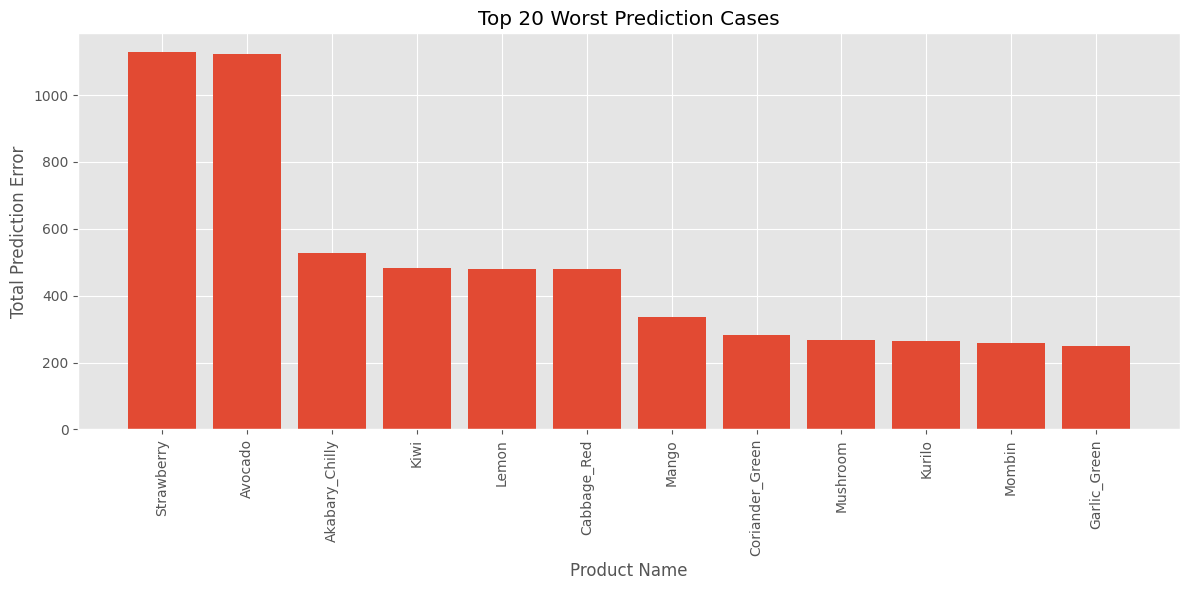

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    worst_cases["Product_Name"],
    worst_cases["Total_Error"]
)

plt.xticks(rotation=90)

plt.xlabel("Product Name")
plt.ylabel("Total Prediction Error")
plt.title("Top 20 Worst Prediction Cases")

plt.tight_layout()
plt.show()

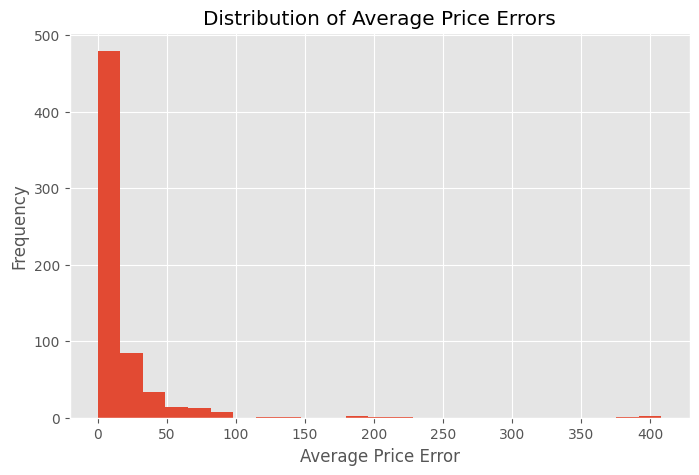

In [26]:
plt.figure(figsize=(8,5))

plt.hist(results["Avg_Error"], bins=25)

plt.xlabel("Average Price Error")
plt.ylabel("Frequency")
plt.title("Distribution of Average Price Errors")

plt.show()

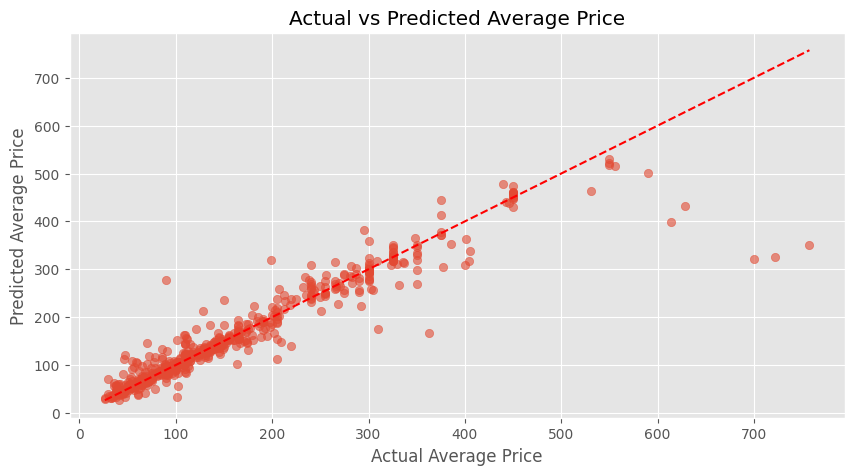

In [27]:
plt.figure(figsize=(10,5))

plt.scatter(
    results["Actual_Avg_Price_next"],
    results["Predicted_Avg_Price_next"],
    alpha=0.6
)

plt.plot(
    [
        results["Actual_Avg_Price_next"].min(),
        results["Actual_Avg_Price_next"].max()
    ],
    [
        results["Actual_Avg_Price_next"].min(),
        results["Actual_Avg_Price_next"].max()
    ],
    "r--"
)

plt.xlabel("Actual Average Price")
plt.ylabel("Predicted Average Price")
plt.title("Actual vs Predicted Average Price")

plt.show()

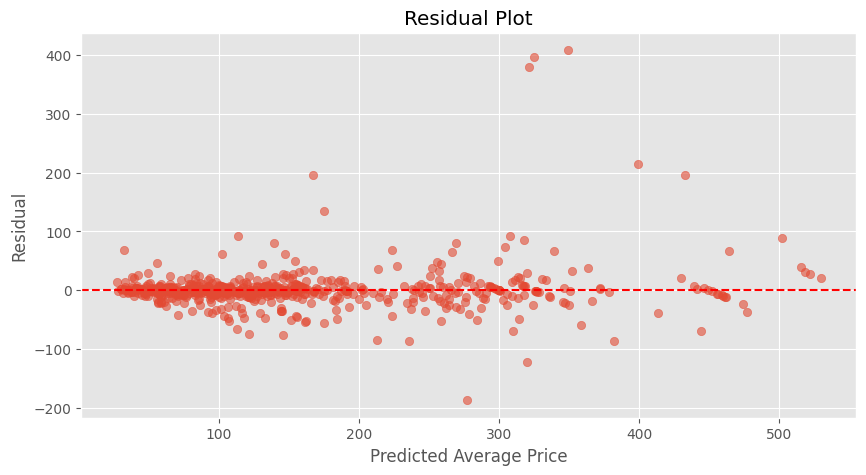

In [28]:
results["Residual"] = (
    results["Actual_Avg_Price_next"] -
    results["Predicted_Avg_Price_next"]
)

plt.figure(figsize=(10,5))

plt.scatter(
    results["Predicted_Avg_Price_next"],
    results["Residual"],
    alpha=0.6
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Average Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [31]:
results["MAPE"] = (
    abs(
        (results["Actual_Avg_Price_next"] -
         results["Predicted_Avg_Price_next"])
        / results["Actual_Avg_Price_next"]
    )
) * 100

print(f"Average MAPE: {results['MAPE'].mean():.2f}%")

Average MAPE: 11.35%


In [30]:
best_cases = results.sort_values(
    by="Total_Error"
).head(20)

best_cases

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next,Min_Error,Avg_Error,Max_Error,Total_Error,Residual,MAPE
301,Haluwabed,5,300.0,300.54,300.00,300.54,300.0,300.54,0.54,0.54,0.54,1.62,-0.54,0.180000
387,Onion_Dry,6,38.0,39.29,50.83,51.32,70.0,69.71,1.29,0.49,0.29,2.07,-0.49,0.963998
598,Sweet_Potato,5,100.0,100.35,110.00,108.49,120.0,119.47,0.35,1.51,0.53,2.39,1.51,1.372727
56,Banana,3,100.0,101.18,115.00,114.31,130.0,130.65,1.18,0.69,0.65,2.52,0.69,0.600000
57,Banana,4,100.0,100.69,115.00,114.36,130.0,131.22,0.69,0.64,1.22,2.55,0.64,0.556522
186,Christophine,4,30.0,32.00,35.00,35.20,40.0,40.41,2.00,0.20,0.41,2.61,-0.20,0.571429
591,Sweet_Pepper,7,100.0,99.45,115.00,116.81,130.0,130.27,0.55,1.81,0.27,2.63,-1.81,1.573913
477,Pumpkin,5,50.0,49.48,55.00,56.21,60.0,61.40,0.52,1.21,1.40,3.13,-1.21,2.200000
471,Potato_W,5,30.0,30.42,32.50,30.42,35.0,34.28,0.42,2.08,0.72,3.22,2.08,6.400000
456,Potato_Blue,3,40.0,39.98,45.00,41.96,50.0,50.24,0.02,3.04,0.24,3.30,3.04,6.755556
